# Load and prepare:

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
logging.basicConfig(level=logging.INFO)

from src.data_loader import load_cmapss, add_rul_to_train, create_anomaly_labels, get_sensor_columns
from src.preprocessing import remove_constant_sensors, normalize_global, clip_rul
from src.feature_engineering import build_feature_pipeline

train_df, test_df, rul_df = load_cmapss('FD001')
train_df = add_rul_to_train(train_df)
train_df = create_anomaly_labels(train_df, threshold=30)
sensor_cols = get_sensor_columns(train_df)
train_df, kept_sensors = remove_constant_sensors(train_df, sensor_cols)

print(f"Kept sensors ({len(kept_sensors)}): {kept_sensors}")

INFO:src.data_loader:Loaded FD001: train=20631 rows, test=13096 rows, 100 engines
INFO:src.data_loader:Anomaly labels: 3100 anomalous (15.0%) out of 20631 samples
INFO:src.preprocessing:Dropped constant sensors: {'sensor_5', 'sensor_18', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_19'}


Kept sensors (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


# Run feature pipeline:

In [2]:
featured_df = build_feature_pipeline(
    train_df, kept_sensors,
    rolling_windows=[5, 10, 20],
    lags=[1, 5],
    ewma_spans=[5, 15]
)
print(f"Shape: {featured_df.shape}")
print(f"New columns: {featured_df.shape[1] - train_df.shape[1]}")

INFO:src.feature_engineering:Starting feature engineering pipeline...
INFO:src.feature_engineering:Added 90 rolling features
INFO:src.feature_engineering:Added 60 lag features
INFO:src.feature_engineering:Added 30 EWMA features
INFO:src.feature_engineering:Added 30 statistical features
INFO:src.feature_engineering:Final feature count: 233 columns


Shape: (20631, 233)
New columns: 211


# Visualize feature importance (correlation with anomaly label):

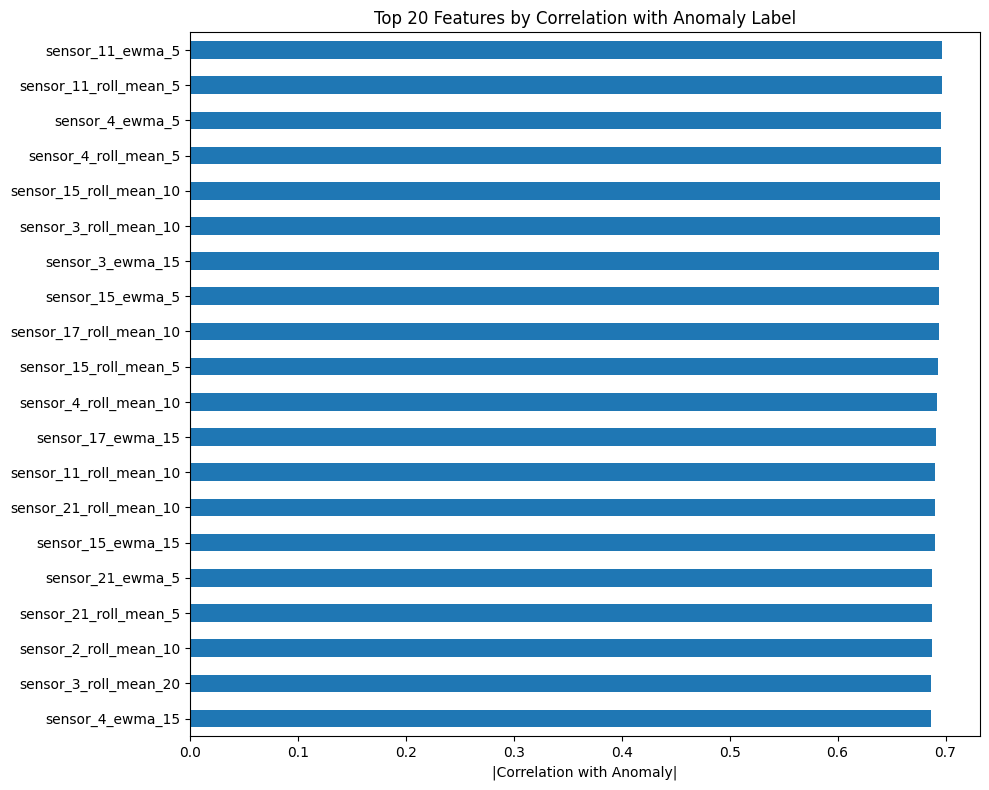

In [3]:
feature_cols = [c for c in featured_df.columns
                if c not in ['unit_id', 'cycle', 'rul', 'anomaly']]

correlations = featured_df[feature_cols + ['anomaly']].corr()['anomaly'].drop('anomaly')
top_features = correlations.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_features.plot.barh(ax=ax)
ax.set_xlabel('|Correlation with Anomaly|')
ax.set_title('Top 20 Features by Correlation with Anomaly Label')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#  Summary:

## Feature Engineering Summary

- Generated ~300+ features from 14 active sensors
- Top correlated features are rolling means and EWMA features - degradation trends matter more than raw readings
- Lag/diff features capture rate-of-change, useful for detecting sudden shifts